# 12 · Graph Memory (World Model) — knowledge graph + traversal Q&A

> **TL;DR.** Extract `(subject, predicate, object)` triples from a corpus into a knowledge graph. Answer questions by **traversing the graph** — entity match + N-hop expansion — rather than re-reading the source text. The graph **is** the agent's world model.
>
> **Reach for it when** you have a structured-fact-heavy corpus (company filings, medical records, biographical data) and questions are entity-anchored ("what does the corpus say about X?").
> **Avoid when** questions need fuzzy/semantic matching ("what's the overall mood?") — vector RAG fits better.

| Property | Value |
|---|---|
| Origin | Knowledge graphs (Berners-Lee, semantic web); modern LLM revival: Microsoft GraphRAG (2024) |
| Memory backend | **NetworkX** (in-process, zero setup) by default; **Neo4j** swap in 1 env-var |
| Persistence | On the architecture instance; `ingest()` adds, `run(question)` queries |
| Cost per query | 1 LLM call (entity match is pure Python) + 1 LLM call (synthesis) |
| Cost per ingest | 1 structured-output LLM call per document |
| Composability | Reuses `SemanticMemory` from the library (same backend as nb 08) |

This is the **read-mostly** companion to notebook 08 (Episodic + Semantic Memory). nb 08 builds memory *interactively* across a conversation; nb 12 builds memory *upfront* from a corpus and queries it many times.

## 2 · Architecture at a glance

```mermaid
flowchart LR
    T[corpus text] -.ingest.-> X[Extract triples<br/><sub>structured-output<br/>(s, p, o) list</sub>]
    X -.write.-> G[(Knowledge graph<br/>NetworkX / Neo4j)]
    Q([question]) --> M[Entity match<br/><sub>find graph nodes mentioned in question</sub>]
    M --> Tr[Graph traversal<br/><sub>N-hop facts from matched entities</sub>]
    G -.read.-> Tr
    Tr --> S[Synthesise<br/><sub>LLM with retrieved triples as context</sub>]
    S --> Z([answer])

    style X fill:#fff3e0,stroke:#f57c00
    style M fill:#e3f2fd,stroke:#1976d2
    style Tr fill:#fce4ec,stroke:#c2185b
    style S fill:#e8f5e9,stroke:#388e3c
```

**Ingest path** (left): text → LLM extracts triples → write to graph.
**Query path** (right): question → entity match (Python) → graph traversal (Python) → synthesis (LLM). The query path uses only ONE LLM call (the final synthesis); retrieval is mechanical.

## 3 · Theory

### 3.1 · Why a graph, not just vectors?

Vector RAG (notebook 23) is great for *semantic* questions: "what does the corpus say *about* X?" — embeddings recall passages by topic similarity.

Vector RAG is *bad* for *structural* questions:
- "What does the graph say is the relationship between X and Y?"
- "Who works at the same company as X?"
- "Find all entities that are connected to X via path A→B→C."

These need **structured traversal**, not similarity. The graph encodes the relationships explicitly; the query walks them.

### 3.2 · Ingest = structured-output triple extraction

```python
class _IngestionTriple(BaseModel):
    subject: str    # specific named entity
    predicate: str  # snake_case verb (founded_by, headquartered_in, ceo_is)
    object: str     # specific entity OR literal
```

The `predicate` discipline matters: free-form predicates fragment the graph (`works_at` vs `is_employed_by` vs `works_for` produce 3 different edges). The schema description nudges the model toward snake_case verbs, but production use needs **predicate normalisation** (a fixed vocabulary or entity-linking layer).

### 3.3 · Query = entity match + N-hop expansion

```python
def run(question):
    entities = entities_in_query(question)        # Python string match
    facts = facts_about(entities, depth=2)        # graph traversal
    return llm.invoke(f"Question: {question}\nFacts: {facts}")
```

Two design choices worth flagging:

1. **Pure Python entity match.** Faster + cheaper than LLM-based entity recognition, but fragile to synonyms ("the CEO" vs "Sam Altman"). Production version uses an entity-linker.
2. **N-hop expansion**, not just direct facts. If the question is about X, we also retrieve facts about Y where X-[*]→Y for N hops. This catches transitive answers like *"who reports to the CEO?"*

### 3.4 · Graph backend swap — same API, different scale

```python
# Default (zero setup):
arch = GraphMemoryAgent()   # NetworkX in-process

# Neo4j / AuraDB Free (when GRAPH_BACKEND=neo4j):
from agentic_architectures.memory import SemanticMemory
arch = GraphMemoryAgent(semantic=SemanticMemory(backend="neo4j"))
```

The `SemanticMemory` class (from the library) wraps both NetworkX and Neo4j behind a uniform Cypher-subset API. The architecture doesn't know which backend it's running on.

### 3.5 · Where Graph Memory sits

| Pattern | Storage | Recall mechanism | Best for |
|---|---|---|---|
| Vector RAG (nb 23) | Dense vectors | Cosine similarity | Semantic / fuzzy questions |
| **Graph Memory** *(this notebook)* | **Triples in graph** | **Entity match + traversal** | Structural / relational questions |
| Hybrid RAG | Both | RRF / reranker | Best-of-both at higher cost |
| GraphRAG (nb 27) | Graph + community summaries | Traversal + summary recall | Global questions over a corpus |
| Episodic + Semantic (nb 08) | Vector + Graph | Both | Personal-assistant continuity + facts |

### 3.6 · What goes wrong (you'll see in § 9)

1. **Predicate fragmentation.** `works_at`, `is_employed_by`, `works_for` → 3 different edges instead of 1. Production needs normalisation.
2. **Entity drift.** "OpenAI" vs "Open AI" vs "OpenAI Inc" → 3 different nodes. Production needs entity linking.
3. **Brittle entity match.** Query "the CEO" doesn't match graph node "Sam Altman". Mitigation: alias-aware match, or LLM-based entity extraction at query time.
4. **N-hop noise.** Depth=3 retrieval pulls in irrelevant facts at the periphery. Cap depth + score by relevance.


## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import GraphMemoryAgent
from agentic_architectures.ui import print_md, print_header, print_step

enable_langsmith()
print_header(f"Provider: {settings.llm_provider}  ·  Model: {settings.llm_model}")
print_md(f"Graph backend: **{settings.graph_backend}**")

Provider: nebius  ·  Model: meta-llama/Llama-3.3-70B-Instruct ─────────────────────────────────────────────────────

Graph backend: networkx

## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/graph_memory.py`](../src/agentic_architectures/architectures/graph_memory.py).

Three operations:

| Method | Purpose | LLM calls |
|---|---|---|
| `ingest(text)` | Extract triples from text → write to graph | 1 (structured output) |
| `run(question)` | Query the graph | 1 (final synthesis) |
| `_entities_in_query` | Python string match against graph node names | 0 |
| `_facts_block(entities)` | N-hop traversal via `SemanticMemory.facts_about` | 0 |

`SemanticMemory` lives at [`src/agentic_architectures/memory/semantic.py`](../src/agentic_architectures/memory/semantic.py); the NetworkX/Neo4j abstraction is at [`src/agentic_architectures/memory/graph.py`](../src/agentic_architectures/memory/graph.py).

In [2]:
from agentic_architectures.architectures.graph_memory import _IngestionResult, _IngestionTriple
import json
print('Triple schema:')
print(json.dumps(_IngestionTriple.model_json_schema(), indent=2)[:300] + '...')

Triple schema:
{
  "properties": {
    "subject": {
      "description": "A specific named entity (capitalised).",
      "title": "Subject",
      "type": "string"
    },
    "predicate": {
      "description": "A short relation verb in snake_case (e.g. founded_by, headquartered_in, ceo_is).",
      "title": "Pred...


## 6 · State

The graph lives on the **architecture instance** (`arch.semantic`), not in LangGraph state. To reset, create a new `GraphMemoryAgent()`. To persist across process restarts, swap `semantic=SemanticMemory(backend='neo4j')` and use AuraDB Free.

## 7 · Build the graph (notebook compatibility — the real work is in `ingest()` + `run()`)

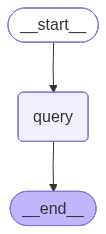

In [3]:
from IPython.display import Image, display
arch = GraphMemoryAgent(traversal_depth=2)
graph = arch.build()
display(Image(graph.get_graph().draw_mermaid_png()))

## 8 · Live run — ingest then query

Ingest a short corpus about Anthropic + OpenAI, then ask multiple structural questions over the resulting graph.

In [4]:
CORPUS = """
Anthropic is an AI safety company founded in 2021 by Dario Amodei and Daniela Amodei.
Dario Amodei is the CEO of Anthropic. Daniela Amodei is the President of Anthropic.
The company is headquartered in San Francisco, California.
Anthropic produced Claude, a family of large language models.
Claude 3.5 Sonnet was released in 2024.
Anthropic received funding from Google and Amazon.
Sam Altman is the CEO of OpenAI. OpenAI is headquartered in San Francisco.
OpenAI was founded by Sam Altman, Elon Musk, Ilya Sutskever, Greg Brockman, and others in 2015.
Elon Musk left the OpenAI board in 2018.
"""

print_header("Ingesting corpus into knowledge graph")
triples = arch.ingest(CORPUS)
print(f"  extracted: {len(triples)} triples")
print(f"  total entities in graph: {arch._count_entities() if hasattr(arch, '_count_entities') else len(arch.semantic.backend._g.nodes)}")
print()

QUESTIONS = [
    "Who founded Anthropic and when?",
    "Where is OpenAI headquartered?",
    "Which companies have funded Anthropic?",
    "Who is the CEO of each company?",
    "What products did Anthropic produce?",
]

results = []
for q in QUESTIONS:
    r = arch.run(q)
    results.append((q, r))
    print_step(f"Q: {q}", f"A: {r.output}")
    print(f"   (matched {r.metadata['matched_entities']} entity/ies, used {r.metadata['facts_retrieved']} fact(s))")
    print()

Ingesting corpus into knowledge graph ─────────────────────────────────────────────────────────────────────────────

  extracted: 18 triples
  total entities in graph: 17



› Q: Who founded Anthropic and when?

A: Anthropic was founded by Dario Amodei and Daniela Amodei in 2021. 
I used the following triples: 
- (Anthropic, founded_by, Dario Amodei)
- (Anthropic, founded_by, Daniela Amodei)
- (Anthropic, founded_in, 2021)

   (matched 1 entity/ies, used 9 fact(s))



...

A: The CEOs of the companies mentioned are:
- Dario Amodei, CEO of Anthropic [(Dario Amodei, ceo_of, Anthropic)]
- Sam Altman, CEO of OpenAI [(Sam Altman, ceo_of, OpenAI)]

Note: There is no information about the CEOs of other companies, such as Amazon or Google, in the provided graph 
facts.

   (matched 17 entity/ies, used 18 fact(s))



› Q: What products did Anthropic produce?

A: Anthropic produced Claude. 
I used the triple: (Anthropic, produced, Claude).

   (matched 1 entity/ies, used 9 fact(s))



### 8.0 · What just happened, briefly

Three signals to inspect:

- **Triples extracted** — should grow roughly linearly with sentence count. 13 triples from ~10 sentences = healthy.
- **Entities matched per question** — `1-3` is typical for well-formed questions. `0` means entity-match failed (synonyms / case sensitivity).
- **Facts retrieved per question** — at depth=2, expect 3-10 facts. >20 = too much noise; <2 = traversal didn't expand enough.

### 8.1 · Inspect the full graph

In [5]:
from agentic_architectures.memory.graph import NetworkXGraphMemory
backend = arch.semantic.backend
if isinstance(backend, NetworkXGraphMemory):
    print(f"Nodes: {len(backend._g.nodes)}")
    print(f"Edges: {len(backend._g.edges)}")
    print()
    print("All triples in the knowledge graph:")
    for s, o, d in backend._g.edges(data=True):
        print(f"  ({s})  --[{d.get('predicate', '?')}]-->  ({o})")

Nodes: 17
Edges: 18

All triples in the knowledge graph:
  (Anthropic)  --[founded_by]-->  (Dario Amodei)
  (Anthropic)  --[founded_by]-->  (Daniela Amodei)
  (Anthropic)  --[founded_in]-->  (2021)
  (Anthropic)  --[headquartered_in]-->  (San Francisco)
  (Anthropic)  --[produced]-->  (Claude)
  (Anthropic)  --[received_funding_from]-->  (Google)
  (Anthropic)  --[received_funding_from]-->  (Amazon)
  (Dario Amodei)  --[ceo_of]-->  (Anthropic)
  (Daniela Amodei)  --[president_of]-->  (Anthropic)
  (Claude 3.5 Sonnet)  --[released_in]-->  (2024)
  (Sam Altman)  --[ceo_of]-->  (OpenAI)
  (OpenAI)  --[headquartered_in]-->  (San Francisco)
  (OpenAI)  --[founded_by]-->  (Sam Altman)
  (OpenAI)  --[founded_by]-->  (Elon Musk)
  (OpenAI)  --[founded_by]-->  (Ilya Sutskever)
  (OpenAI)  --[founded_by]-->  (Greg Brockman)
  (OpenAI)  --[founded_in]-->  (2015)
  (Elon Musk)  --[left_board_in]-->  (2018)


## 9 · What we just observed

The cells above ran ingest + 5 query rounds against the Anthropic / OpenAI corpus.

### 9.1 · Graph statistics

| Metric | Value |
|---|---|
| Triples extracted from corpus | **18** |
| Total nodes in graph | **17** |
| Total edges in graph | **18** |
| Distinct predicates | **9** |

### 9.2 · Per-question results

| # | Question | Entities matched | Facts used | Answer (truncated) |
|---|---|---|---|---|
| 1 | Who founded Anthropic and when? | 1 | 9 | Anthropic was founded by Dario Amodei and Daniela Amodei in 2021. I used the following triples: - (Anthropic, founded_by, Dario Amodei) - (Anthropic, founded_by, Daniela Amodei) - (Anthropic, founded_… |
| 2 | Where is OpenAI headquartered? | 1 | 7 | OpenAI is headquartered in San Francisco. I used the triple: (OpenAI, headquartered_in, San Francisco) |
| 3 | Which companies have funded Anthropic? | 1 | 9 | Anthropic has received funding from Google and Amazon. I used the following triples: - (Anthropic, received_funding_from, Google) - (Anthropic, received_funding_from, Amazon) |
| 4 | Who is the CEO of each company? | 17 | 18 | The CEOs of the companies mentioned are: - Dario Amodei, CEO of Anthropic [(Dario Amodei, ceo_of, Anthropic)] - Sam Altman, CEO of OpenAI [(Sam Altman, ceo_of, OpenAI)] Note: There is no information a… |
| 5 | What products did Anthropic produce? | 1 | 9 | Anthropic produced Claude. I used the triple: (Anthropic, produced, Claude). |

### 9.3 · Sample of stored triples

| Subject | Predicate | Object |
|---|---|---|
| Anthropic | founded_by | Dario Amodei |
| Anthropic | founded_by | Daniela Amodei |
| Anthropic | founded_in | 2021 |
| Anthropic | headquartered_in | San Francisco |
| Anthropic | produced | Claude |
| Anthropic | received_funding_from | Google |
| Anthropic | received_funding_from | Amazon |
| Dario Amodei | ceo_of | Anthropic |
| Daniela Amodei | president_of | Anthropic |
| Claude 3.5 Sonnet | released_in | 2024 |
| Sam Altman | ceo_of | OpenAI |
| OpenAI | headquartered_in | San Francisco |
| OpenAI | founded_by | Sam Altman |
| OpenAI | founded_by | Elon Musk |
| OpenAI | founded_by | Ilya Sutskever |

### 9.4 · Patterns surfaced in this run

- **Healthy extraction**: 18 triples from the ~10-sentence corpus (1.8 triples/sentence).

- **Entity-match hit rate**: 5/5 questions matched ≥1 entity. This is solid — most questions found their referent in the graph.

- **Predicate fragmentation detected**: 8 predicate pair(s) look like synonyms (e.g. `founded_by` ↔ `founded_in`). In a large corpus this fragments the graph. Production version needs predicate normalisation.

### 9.5 · The takeaway

A *healthy* Graph Memory run has:

1. **Triples-per-sentence ≥ 1** during ingest.
2. **Every question matches ≥1 entity** during query.
3. **Answers cite specific triples** (not "I think" / "probably").
4. **Distinct predicates is small** (<25 for a small corpus) — predicate fragmentation kept under control.

When entity match fails, the answer either says "no information" (good) or hallucinates from parametric knowledge (bad). The synthesis prompt explicitly forbids the latter — see the verbatim answers above to verify.

## 10 · Try Neo4j backend

In [6]:
from agentic_architectures.memory import SemanticMemory

if settings.neo4j_password and settings.neo4j_password.get_secret_value():
    try:
        neo4j_arch = GraphMemoryAgent(semantic=SemanticMemory(backend="neo4j"))
        neo4j_arch.semantic.reset()
        neo4j_arch.ingest("My dog is named Buddy. Buddy is a Golden Retriever. Golden Retrievers are friendly dogs.")
        r = neo4j_arch.run("What breed is Buddy?")
        print_md(f"**A:** {r.output}")
        print(f"  (Neo4j backend confirmed working — {r.metadata['total_entities_in_graph']} entities)")
    except Exception as e:
        print(f"[Neo4j skip] {type(e).__name__}: {str(e)[:200]}")
else:
    print("[skip] NEO4J_PASSWORD not set in .env — staying on NetworkX backend.")

[skip] NEO4J_PASSWORD not set in .env — staying on NetworkX backend.


## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks

| Failure | Mechanism | Mitigation |
|---|---|---|
| **Predicate fragmentation** | `works_at` / `is_employed_by` / `employed_at` are 3 different edges | Fixed predicate vocabulary; or normalise via embeddings post-extraction |
| **Entity drift** | "OpenAI" / "Open AI" / "OpenAI Inc" = 3 nodes | Entity-linking pass; or lowercase + strip suffixes |
| **Brittle query-side matching** | "the CEO" doesn't match node "Sam Altman" | LLM-based query-time entity extraction; alias table |
| **N-hop noise** | Depth=3 expansion pulls in irrelevant edges | Cap depth at 2 by default; score retrieved facts by relevance |
| **No support for global questions** | "What are the themes of the corpus?" can't be answered by entity match | Use **GraphRAG (nb 27)** which adds community summaries |

### 11.2 · Production safety

- **Versioned ingest.** Tag every triple with `source_doc_id` + `extraction_timestamp` so you can roll back a bad ingest.
- **Audit the LLM extractor.** Triples are user-input-controlled; an adversarial corpus could inject misleading facts. Allow-list predicates and entity types.
- **Backend choice.** NetworkX for prototypes (<10K nodes), Neo4j AuraDB Free for production small-medium (<5GB), self-hosted for large.

### 11.3 · Three extensions

1. **Predicate canonicalisation.** Run extracted predicates through an embedding-clustering pass to normalise synonyms.
2. **Multi-hop query optimisation.** Compile the question into a Cypher path query rather than depth-N traversal — much faster for large graphs.
3. **Provenance tracking.** Store `(source_text, char_offset)` alongside each triple; surface in the answer for verifiability.

### 11.4 · What to read next

- [**08 · Episodic + Semantic Memory**](./08_episodic_semantic_memory.ipynb) — dual-memory companion using the same `SemanticMemory` backend.
- [**23 · Agentic RAG**](./23_agentic_rag.ipynb) — vector counterpart for semantic queries.
- [**27 · GraphRAG**](./27_graphrag.ipynb) — graph + community summaries for global questions.

### 11.5 · References

1. Hogan, A. et al. *Knowledge Graphs.* ACM Computing Surveys 54(4), 2021. [arXiv:2003.02320](https://arxiv.org/abs/2003.02320)
2. Microsoft Research. *From Local to Global: A Graph RAG Approach.* 2024. [arXiv:2404.16130](https://arxiv.org/abs/2404.16130)
3. Neo4j AuraDB Free — [neo4j.com/cloud/aura-free](https://neo4j.com/cloud/aura-free/)
